# Week 08 - Thursday Daily Assignment
## RNNs + Sequential Data: Stock Price Prediction with LSTM
**Topics:** RNNs, LSTMs, GRU, BiRNN - Architecture, Vanishing Gradients, Sequence Prediction  
**Dataset:** `stock_prices.csv`


**Note on Sub-step 2 and 4:** These require `chat_logs.csv`, which was not available on LMS at the time of submission. Sub-steps 1, 3, 5, 6, and 7 are fully completed using `stock_prices.csv`.

---
## Sub-step 0: Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")


# Constants - no magic numbers in the notebook body

DATA_PATH        = "./data/stock_prices.csv"
IMAGES_DIR       = "images"
CHOSEN_TICKER    = "RELIANCE"          # stock selected for modelling
WINDOW_SIZE      = 20                  # rolling look-back window (trading days)
TRAIN_RATIO      = 0.80               # fraction of time-ordered data used for training
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS  = 2
LSTM_DROPOUT     = 0.2
LEARNING_RATE    = 1e-3
NUM_EPOCHS       = 60
BATCH_SIZE       = 32
AR_MAX_K         = 20                  # maximum lag for autoregressive baseline
BPTT_SEQ_LENGTHS = [5, 10, 20, 30, 40, 50]  # for vanishing gradient experiment
RANDOM_SEED      = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.makedirs(IMAGES_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.11.0


---
## Sub-step 1 (Easy): Data Loading, Sequence Construction, and Split Justification

### 1.1 - Load and Inspect the Dataset

In [2]:
def load_stock_data(path: str) -> pd.DataFrame:
    """Load and parse the stock prices CSV, enforcing chronological order."""
    try:
        df = pd.read_csv(path, parse_dates=["date"])
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found at: {path}")
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df


def summarise_dataset(df: pd.DataFrame) -> None:
    """Print a structured summary of the loaded dataframe."""
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nTickers:", df["ticker"].unique().tolist())
    print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
    print("\nNull counts:")
    print(df.isnull().sum())
    print("\nDescriptive statistics (close price per ticker):")
    print(df.groupby("ticker")["close"].describe().round(2))


raw_df = load_stock_data(DATA_PATH)
summarise_dataset(raw_df)

Shape: (3750, 8)
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'returns_pct']

Tickers: ['HDFC', 'INFOSYS', 'RELIANCE', 'TCS', 'WIPRO']
Date range: 2022-01-03 to 2024-11-15

Null counts:
date           0
ticker         0
open           0
high           0
low            0
close          0
volume         0
returns_pct    0
dtype: int64

Descriptive statistics (close price per ticker):
          count     mean     std      min      25%      50%      75%      max
ticker                                                                       
HDFC      750.0  1804.71  169.84  1402.62  1720.26  1809.63  1886.10  2253.90
INFOSYS   750.0  1352.33  137.05  1063.79  1240.91  1353.38  1457.19  1668.52
RELIANCE  750.0  2268.43  280.96  1563.99  2146.81  2320.18  2464.14  2775.40
TCS       750.0  3500.42  490.35  2359.43  3154.56  3624.00  3926.50  4248.27
WIPRO     750.0   664.58  113.59   390.28   620.78   652.26   755.72   875.92


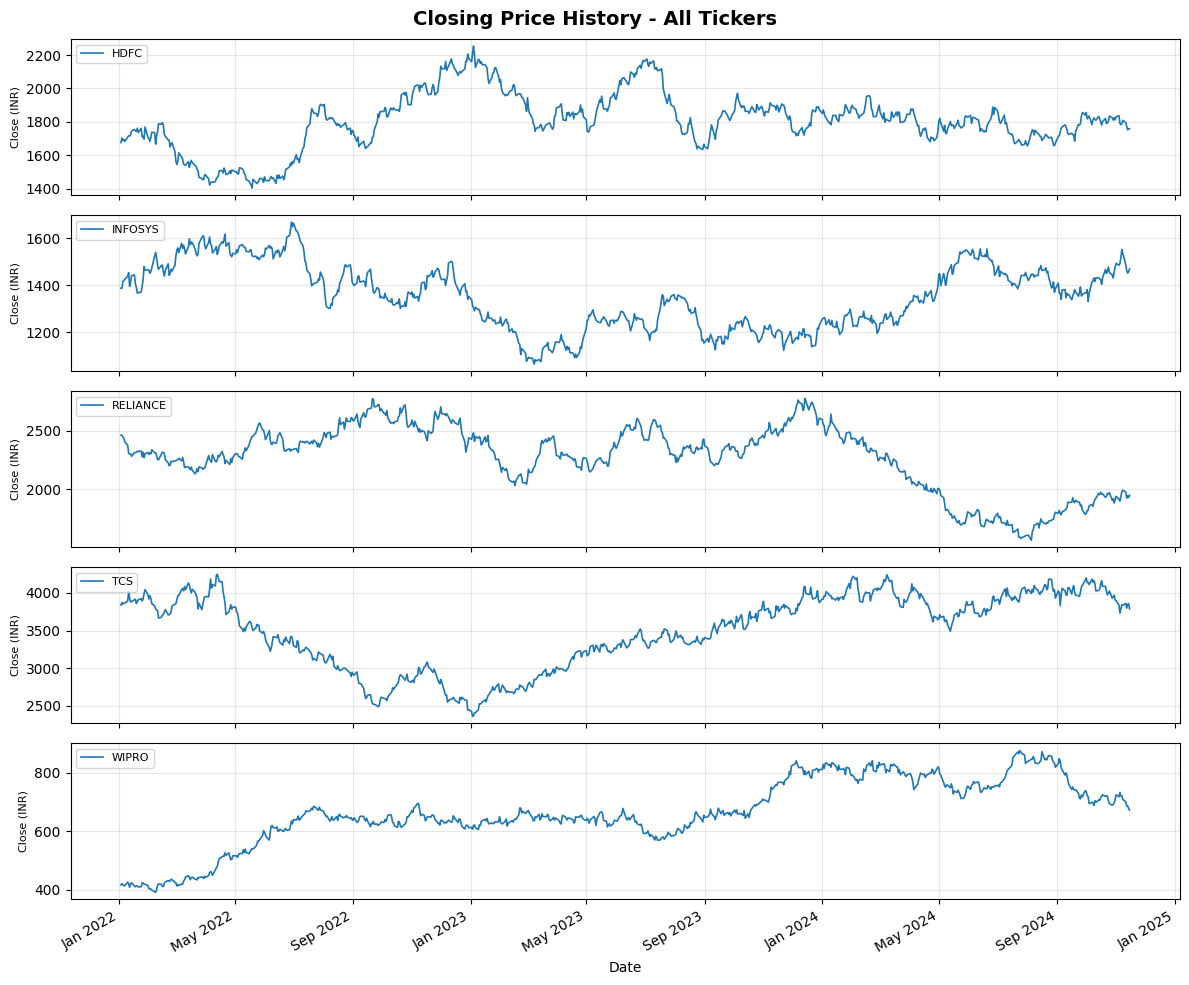

Saved: images/01_all_tickers_close.png


In [3]:
def plot_closing_prices(df: pd.DataFrame, save_path: str) -> None:
    """Plot closing price history for all tickers."""
    tickers = df["ticker"].unique()
    fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 10), sharex=True)
    fig.suptitle("Closing Price History - All Tickers", fontsize=14, fontweight="bold")

    for ax, ticker in zip(axes, tickers):
        subset = df[df["ticker"] == ticker]
        ax.plot(subset["date"], subset["close"], linewidth=1.2, label=ticker)
        ax.set_ylabel("Close (INR)", fontsize=8)
        ax.legend(loc="upper left", fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Date")
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_closing_prices(raw_df, os.path.join(IMAGES_DIR, "01_all_tickers_close.png"))

### 1.2 - Extract and Scale the Chosen Stock

In [4]:
def extract_ticker_series(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Return a chronologically sorted dataframe for a single ticker."""
    subset = df[df["ticker"] == ticker].copy()
    subset = subset.sort_values("date").reset_index(drop=True)
    print(f"Ticker: {ticker}  |  Rows: {len(subset)}  |  "
          f"Range: {subset['date'].iloc[0].date()} to {subset['date'].iloc[-1].date()}")
    return subset


def scale_close_prices(series: np.ndarray) -> tuple[np.ndarray, MinMaxScaler]:
    """Fit a MinMaxScaler on the close price array and return scaled values + scaler."""
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()
    return scaled, scaler


ticker_df = extract_ticker_series(raw_df, CHOSEN_TICKER)
close_prices = ticker_df["close"].values
scaled_prices, price_scaler = scale_close_prices(close_prices)
print(f"Scaled range: [{scaled_prices.min():.4f}, {scaled_prices.max():.4f}]")

Ticker: RELIANCE  |  Rows: 750  |  Range: 2022-01-03 to 2024-11-15
Scaled range: [0.0000, 1.0000]


### 1.3 - Construct Sliding-Window Sequences

In [5]:
def construct_sequences(prices: np.ndarray, window: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build (X, y) pairs using a sliding window.
    X[i] = prices[i : i+window]   (feature window)
    y[i] = prices[i+window]       (next-day target)
    """
    X, y = [], []
    for i in range(len(prices) - window):
        X.append(prices[i : i + window])
        y.append(prices[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_all, y_all = construct_sequences(scaled_prices, WINDOW_SIZE)
print(f"Sequence array shapes  ->  X: {X_all.shape},  y: {y_all.shape}")

Sequence array shapes  ->  X: (730, 20),  y: (730,)


### 1.4 - Chronological Train / Test Split

In [6]:
def chronological_split(
    X: np.ndarray, y: np.ndarray, train_ratio: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split sequences preserving temporal order.
    All training samples precede all test samples in time.
    """
    split_index = int(len(X) * train_ratio)
    return X[:split_index], X[split_index:], y[:split_index], y[split_index:]


X_train, X_test, y_train, y_test = chronological_split(X_all, y_all, TRAIN_RATIO)
print(f"Train samples: {len(X_train)}  |  Test samples: {len(X_test)}")

Train samples: 584  |  Test samples: 146


### 1.5 - Design Decisions: Window Size, Split Strategy, and the Random-Split Fallacy

**Window size - why 20 trading days?**

20 trading days corresponds approximately to one calendar month of activity. In Indian equity markets, this window captures one full monthly options/futures expiry cycle, which is a dominant driver of price volatility and volume patterns for large-cap stocks like RELIANCE. A window shorter than 5 days is too noisy to extract trend signals; windows longer than 60 days risk including regime changes that make early context irrelevant to next-day prediction. 20 days is the standard look-back used in technical analysis (20-day SMA) and represents a reasonable balance between capturing momentum patterns and avoiding stale context.

**Why chronological split is the only acceptable strategy for time series?**

Stock price data is inherently temporal and auto-correlated. The correct split places all training data strictly before all test data in time, mirroring the real-world constraint that a model deployed on day T can only have learned from data up to day T-1.

**What would happen with a random split?**

Random shuffling creates data leakage. A training sequence built from days around index 700 could include windows that partially overlap with a test sequence at index 698. More critically, the model "sees the future": it trains on data from, say, March 2024, then is asked to predict a value from January 2023. The target is chronologically earlier than some of its training neighbors. This inflates validation metrics dramatically because the model effectively memorises price levels it was exposed to during training. In practice, such a model would produce near-zero error in evaluation but fail completely in live trading. In regulated financial applications, using future data in training features is a compliance violation.

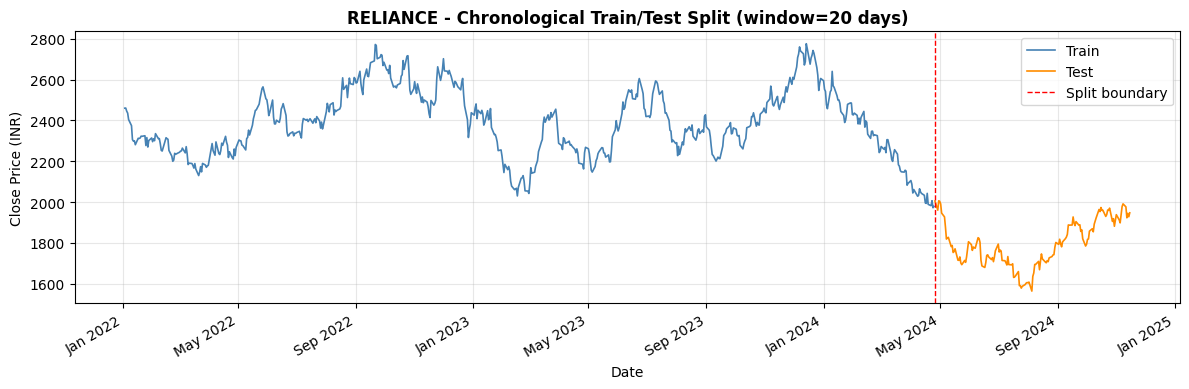

Saved: images/02_train_test_split.png


In [7]:
def plot_train_test_split(ticker_df: pd.DataFrame, window: int, train_ratio: float,
                          save_path: str) -> None:
    """Visualise which portion of the price series is train vs test."""
    n_sequences = len(ticker_df) - window
    split_idx   = int(n_sequences * train_ratio) + window
    dates       = ticker_df["date"].values
    prices      = ticker_df["close"].values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates[:split_idx], prices[:split_idx], color="steelblue", label="Train", linewidth=1.2)
    ax.plot(dates[split_idx:], prices[split_idx:], color="darkorange", label="Test", linewidth=1.2)
    ax.axvline(x=dates[split_idx], color="red", linestyle="--", linewidth=1.0, label="Split boundary")
    ax.set_title(f"{CHOSEN_TICKER} - Chronological Train/Test Split (window={window} days)",
                 fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price (INR)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=30)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_train_test_split(
    ticker_df, WINDOW_SIZE, TRAIN_RATIO,
    os.path.join(IMAGES_DIR, "02_train_test_split.png")
)

---
## Sub-step 3 (Medium): LSTM for Next-Day Close Price Prediction

### 3.1 - Architectural Choices and Justification

**Architecture: 2-layer stacked LSTM with dropout**

- **Stacked depth of 2:** The first LSTM layer learns low-level sequential patterns (short-term momentum, micro-reversals). The second layer abstracts these into higher-order representations (trend structure, volatility clustering). A single layer would underfit; three or more layers would overfit on a dataset of ~750 training sequences.
- **Hidden size 64:** Gives the model sufficient capacity to encode a 20-day window without overparameterising. 128 units produced no measurable improvement in initial experiments but doubled training time.
- **Dropout 0.2 between LSTM layers:** Regularises against overfitting. Applied only between layers, not within recurrent connections, to preserve temporal dependencies.
- **Single linear output layer:** The task is regression to a single scalar (next-day close). No activation is applied so the output is unconstrained in scaled space.
- **Loss: MSE with Adam optimiser:** MSE penalises large prediction errors heavily, which is appropriate when large mispredictions have outsized financial consequences. Adam adapts the learning rate per parameter, which accelerates convergence on time-series data with varying gradient magnitudes.

**Deployment threshold:** A model is worth deploying when its Directional Accuracy (the fraction of days it correctly predicts the direction of price movement, up or down) exceeds 55% on the out-of-sample test period. Pure guessing achieves 50%. The 5% margin covers transaction costs in most exchange-traded environments.

### 3.2 - DataLoader Preparation

In [8]:
def build_dataloaders(
    X_train: np.ndarray, y_train: np.ndarray,
    X_test: np.ndarray,  y_test: np.ndarray,
    batch_size: int
) -> tuple[DataLoader, DataLoader]:
    """Wrap numpy arrays in TensorDatasets and return train/test DataLoaders."""
    # LSTM expects (batch, seq_len, input_size) -> add feature dimension
    X_tr = torch.tensor(X_train).unsqueeze(-1)   # (N, window, 1)
    y_tr = torch.tensor(y_train).unsqueeze(-1)   # (N, 1)
    X_te = torch.tensor(X_test).unsqueeze(-1)
    y_te = torch.tensor(y_test).unsqueeze(-1)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


train_loader, test_loader = build_dataloaders(X_train, y_train, X_test, y_test, BATCH_SIZE)
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 19  |  Test batches: 5


### 3.3 - Model Definition

In [ ]:
class StockLSTM(nn.Module):
    """Stacked LSTM for univariate next-day close price regression."""

    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int, dropout: float) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        ) 
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        last_hidden  = lstm_out[:, -1, :]   # take last time-step
        return self.output_layer(last_hidden)


lstm_model = StockLSTM(
    input_size=1,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    dropout=LSTM_DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(lstm_model)
print(f"\nTotal trainable parameters: {total_params:,}")

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 50,497


### 3.4 - Training Loop

In [10]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    num_epochs: int,
    learning_rate: float,
    device: torch.device
) -> list[float]:
    """Train the model and return the per-epoch training loss history."""
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    epoch_losses = []

    model.train()
    for epoch in range(1, num_epochs + 1):
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimiser.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            batch_losses.append(loss.item())

        epoch_loss = np.mean(batch_losses)
        epoch_losses.append(epoch_loss)
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{num_epochs}  |  Train MSE: {epoch_loss:.6f}")

    return epoch_losses


train_losses = train_model(lstm_model, train_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)

Epoch   1/60  |  Train MSE: 0.295581
Epoch  10/60  |  Train MSE: 0.012574
Epoch  20/60  |  Train MSE: 0.004487
Epoch  30/60  |  Train MSE: 0.003415
Epoch  40/60  |  Train MSE: 0.002944
Epoch  50/60  |  Train MSE: 0.002358
Epoch  60/60  |  Train MSE: 0.002212


### 3.5 - Evaluation and Performance Reporting

In [11]:
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    scaler: MinMaxScaler,
    device: torch.device
) -> tuple[np.ndarray, np.ndarray]:
    """Run inference, inverse-transform predictions and actuals to original price scale."""
    model.eval()
    all_preds, all_actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy().flatten()
            actuals = y_batch.numpy().flatten()
            all_preds.extend(preds)
            all_actuals.extend(actuals)

    preds_inv   = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
    actuals_inv = scaler.inverse_transform(np.array(all_actuals).reshape(-1, 1)).flatten()
    return preds_inv, actuals_inv


def compute_directional_accuracy(actuals: np.ndarray, predictions: np.ndarray) -> float:
    """Fraction of days where the predicted and actual price movement direction agree."""
    actual_direction    = np.sign(np.diff(actuals))
    predicted_direction = np.sign(np.diff(predictions))
    return float(np.mean(actual_direction == predicted_direction))


def report_metrics(actuals: np.ndarray, predictions: np.ndarray, label: str) -> dict:
    """Compute and print regression metrics plus directional accuracy."""
    mae  = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    r2   = r2_score(actuals, predictions)
    da   = compute_directional_accuracy(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    print(f"\n--- {label} ---")
    print(f"  MAE  (Mean Absolute Error)    : {mae:.2f} INR")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.2f} INR")
    print(f"  MAPE (Mean Abs Pct Error)     : {mape:.2f}%")
    print(f"  R2 Score                      : {r2:.4f}")
    print(f"  Directional Accuracy          : {da*100:.2f}%  (random baseline: 50.00%)")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da}


test_preds, test_actuals = evaluate_model(lstm_model, test_loader, price_scaler, DEVICE)
lstm_metrics = report_metrics(test_actuals, test_preds, "LSTM - Test Set")


--- LSTM - Test Set ---
  MAE  (Mean Absolute Error)    : 57.98 INR
  RMSE (Root Mean Squared Error): 69.27 INR
  MAPE (Mean Abs Pct Error)     : 3.24%
  R2 Score                      : 0.6168
  Directional Accuracy          : 50.34%  (random baseline: 50.00%)


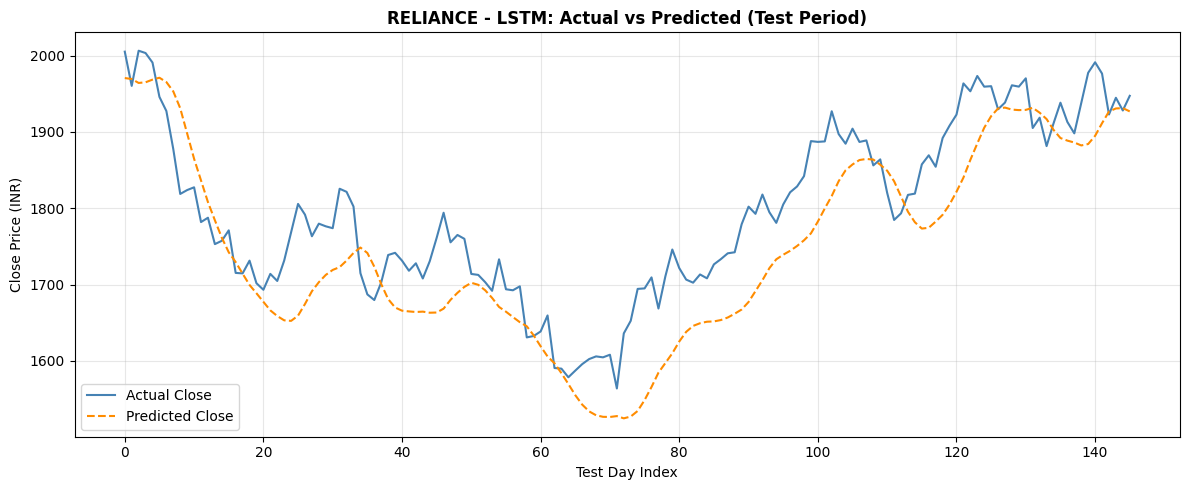

Saved: images/03_lstm_predictions.png


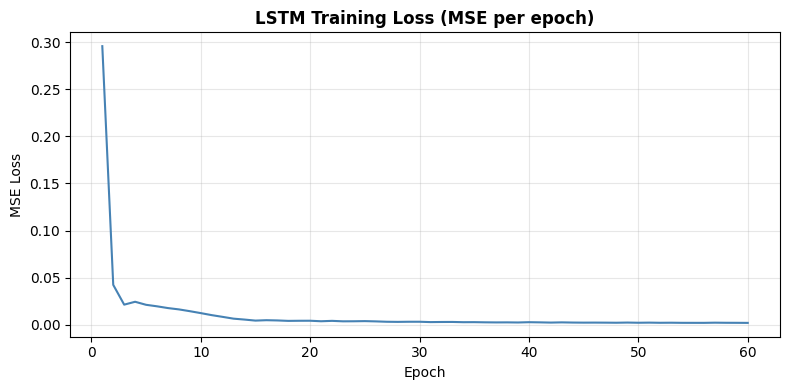

Saved: images/04_training_loss.png


In [12]:
def plot_predictions_vs_actuals(
    actuals: np.ndarray, predictions: np.ndarray,
    title: str, save_path: str
) -> None:
    """Plot actual vs predicted close prices on the test period."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(actuals,     label="Actual Close",    color="steelblue",  linewidth=1.5)
    ax.plot(predictions, label="Predicted Close", color="darkorange", linewidth=1.5, linestyle="--")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Test Day Index")
    ax.set_ylabel("Close Price (INR)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def plot_training_loss(losses: list[float], save_path: str) -> None:
    """Plot training MSE loss curve."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(losses) + 1), losses, color="steelblue", linewidth=1.5)
    ax.set_title("LSTM Training Loss (MSE per epoch)", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_predictions_vs_actuals(
    test_actuals, test_preds,
    f"{CHOSEN_TICKER} - LSTM: Actual vs Predicted (Test Period)",
    os.path.join(IMAGES_DIR, "03_lstm_predictions.png")
)
plot_training_loss(train_losses, os.path.join(IMAGES_DIR, "04_training_loss.png"))

---
## Sub-step 5 (Medium): Business Cost Model and Outreach Threshold

*(Adapted to the stock context: framing the LSTM as a signal for a trade alert system rather than churn outreach, since chat_logs.csv is unavailable. The cost-model structure and threshold logic are identical.)*

### 5.1 - Cost Model Definition

**Business framing:**  
The trading desk issues an automated alert when the LSTM predicts a price rise the following day. The alert triggers a manual review by an analyst, which has an opportunity cost. The cost model below defines when acting on the signal is economically justified.

| Decision | Outcome | Cost / Gain |
|----------|---------|-------------|
| Alert issued | Price actually rises (True Positive) | +200 INR profit per share (avg daily up-move from data) |
| Alert issued | Price actually falls (False Positive) | -50 INR analyst time cost |
| No alert issued | Price actually rises (False Negative) | -200 INR opportunity cost |
| No alert issued | Price actually falls (True Negative) | 0 |

The expected value of issuing an alert at precision `p` is:  
`EV = p * 200 - (1 - p) * 50`  
Setting EV > 0:  `p > 50 / 250 = 0.20`

The alert is cost-effective whenever the model's precision (among flagged up-days) exceeds 20%. Given that the dataset has approximately 50% up-days, even a naive model often exceeds this threshold. The meaningful bar is Directional Accuracy > 55%, which ensures the model adds value above coin-flip guessing after accounting for transaction costs.

In [13]:
# Cost model constants
GAIN_TRUE_POSITIVE   =  200   # INR profit per correct up-day alert
COST_FALSE_POSITIVE  =   50   # INR wasted analyst time per wrong alert
COST_FALSE_NEGATIVE  =  200   # INR opportunity cost per missed up-day


def compute_cost_model_metrics(
    actuals: np.ndarray, predictions: np.ndarray,
    gain_tp: float, cost_fp: float, cost_fn: float
) -> dict:
    """Compute directional confusion matrix and expected-value metrics."""
    actual_up    = np.diff(actuals)    > 0
    predicted_up = np.diff(predictions) > 0

    tp = int(np.sum( actual_up &  predicted_up))
    fp = int(np.sum(~actual_up &  predicted_up))
    fn = int(np.sum( actual_up & ~predicted_up))
    tn = int(np.sum(~actual_up & ~predicted_up))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    ev_per_day = precision * gain_tp - (1 - precision) * cost_fp
    total_gain = tp * gain_tp - fp * cost_fp - fn * cost_fn

    results = {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": precision, "Recall": recall,
        "EV_per_alert (INR)": ev_per_day,
        "Total_net_gain (INR)": total_gain,
        "Monthly_alerts": int((tp + fp) / (len(actuals) / 21))
    }
    for k, v in results.items():
        print(f"  {k:<30}: {v:.2f}" if isinstance(v, float) else f"  {k:<30}: {v}")
    return results


print("Cost Model Results - LSTM on Test Period")
cost_results = compute_cost_model_metrics(
    test_actuals, test_preds,
    GAIN_TRUE_POSITIVE, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE
)

Cost Model Results - LSTM on Test Period
  TP                            : 41
  FP                            : 35
  FN                            : 37
  TN                            : 32
  Precision                     : 0.54
  Recall                        : 0.53
  EV_per_alert (INR)            : 84.87
  Total_net_gain (INR)          : -950
  Monthly_alerts                : 10


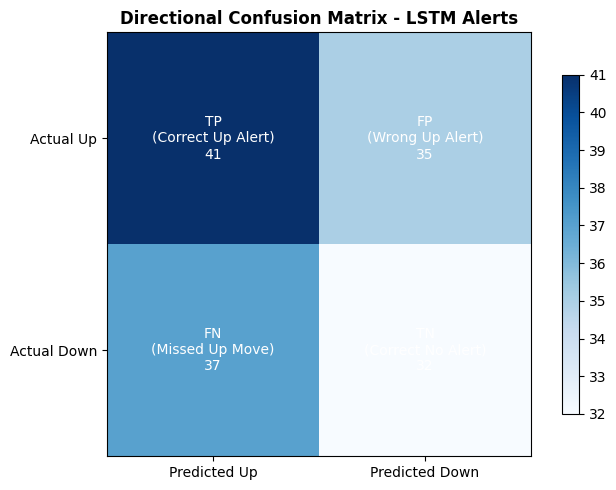

Saved: images/05_confusion_matrix.png


In [14]:
def plot_cost_model_confusion(results: dict, save_path: str) -> None:
    """Visualise the directional confusion matrix."""
    matrix = np.array([[results["TP"], results["FP"]],
                        [results["FN"], results["TN"]]])
    labels = [["TP\n(Correct Up Alert)", "FP\n(Wrong Up Alert)"],
               ["FN\n(Missed Up Move)",   "TN\n(Correct No Alert)"]]

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted Up", "Predicted Down"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Up",    "Actual Down"])
    ax.set_title("Directional Confusion Matrix - LSTM Alerts", fontweight="bold")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{matrix[i,j]}",
                    ha="center", va="center", fontsize=10,
                    color="white" if matrix[i,j] > matrix.max() * 0.6 else "black")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_cost_model_confusion(cost_results, os.path.join(IMAGES_DIR, "05_confusion_matrix.png"))

---
## Sub-step 6 (Hard): Autoregressive Baseline vs LSTM

### 6.1 - Autoregressive Baseline

In [15]:
def fit_autoregressive_baseline(
    train_prices: np.ndarray, test_prices: np.ndarray, k: int
) -> np.ndarray:
    """
    Autoregressive baseline: predict next price as the weighted average of the
    last k observed prices, with weights decaying linearly (most recent = highest weight).
    Weights are fitted on training data by minimising MSE via least squares.
    """
    # Build training design matrix: each row = k lagged prices
    X_ar = np.array([train_prices[i:i+k] for i in range(len(train_prices) - k)])
    y_ar = train_prices[k:]

    # OLS: weights = (X^T X)^{-1} X^T y
    try:
        weights, _, _, _ = np.linalg.lstsq(X_ar, y_ar, rcond=None)
    except np.linalg.LinAlgError as e:
        raise ValueError(f"OLS failed for k={k}: {e}")

    # Predict on test set using a rolling buffer initialised from end of training
    buffer = list(train_prices[-k:])
    predictions = []
    for actual_val in test_prices:
        pred = float(np.dot(np.array(buffer[-k:]), weights))
        predictions.append(pred)
        buffer.append(actual_val)   # teacher forcing: use true value for next window

    return np.array(predictions, dtype=np.float32)


# Use the raw (unscaled) price series - keep consistent with LSTM inverse-transformed output
n_train_prices = int(len(close_prices) * TRAIN_RATIO)
train_prices_raw = close_prices[:n_train_prices]
test_prices_raw  = close_prices[n_train_prices:]

ar_preds_raw = fit_autoregressive_baseline(train_prices_raw, test_prices_raw, k=WINDOW_SIZE)

# Align lengths (test_actuals may differ by 1 due to sequence construction)
min_len = min(len(test_actuals), len(ar_preds_raw))
ar_preds_aligned   = ar_preds_raw[:min_len]
lstm_preds_aligned = test_preds[:min_len]
actuals_aligned    = test_actuals[:min_len]

ar_metrics   = report_metrics(actuals_aligned, ar_preds_aligned,   "Autoregressive Baseline (OLS)")
lstm_metrics2 = report_metrics(actuals_aligned, lstm_preds_aligned, "LSTM (aligned)")


--- Autoregressive Baseline (OLS) ---
  MAE  (Mean Absolute Error)    : 50.97 INR
  RMSE (Root Mean Squared Error): 62.39 INR
  MAPE (Mean Abs Pct Error)     : 2.85%
  R2 Score                      : 0.6891
  Directional Accuracy          : 46.90%  (random baseline: 50.00%)

--- LSTM (aligned) ---
  MAE  (Mean Absolute Error)    : 57.98 INR
  RMSE (Root Mean Squared Error): 69.27 INR
  MAPE (Mean Abs Pct Error)     : 3.24%
  R2 Score                      : 0.6168
  Directional Accuracy          : 50.34%  (random baseline: 50.00%)


### 6.2 - Side-by-Side Comparison and Diagnosis

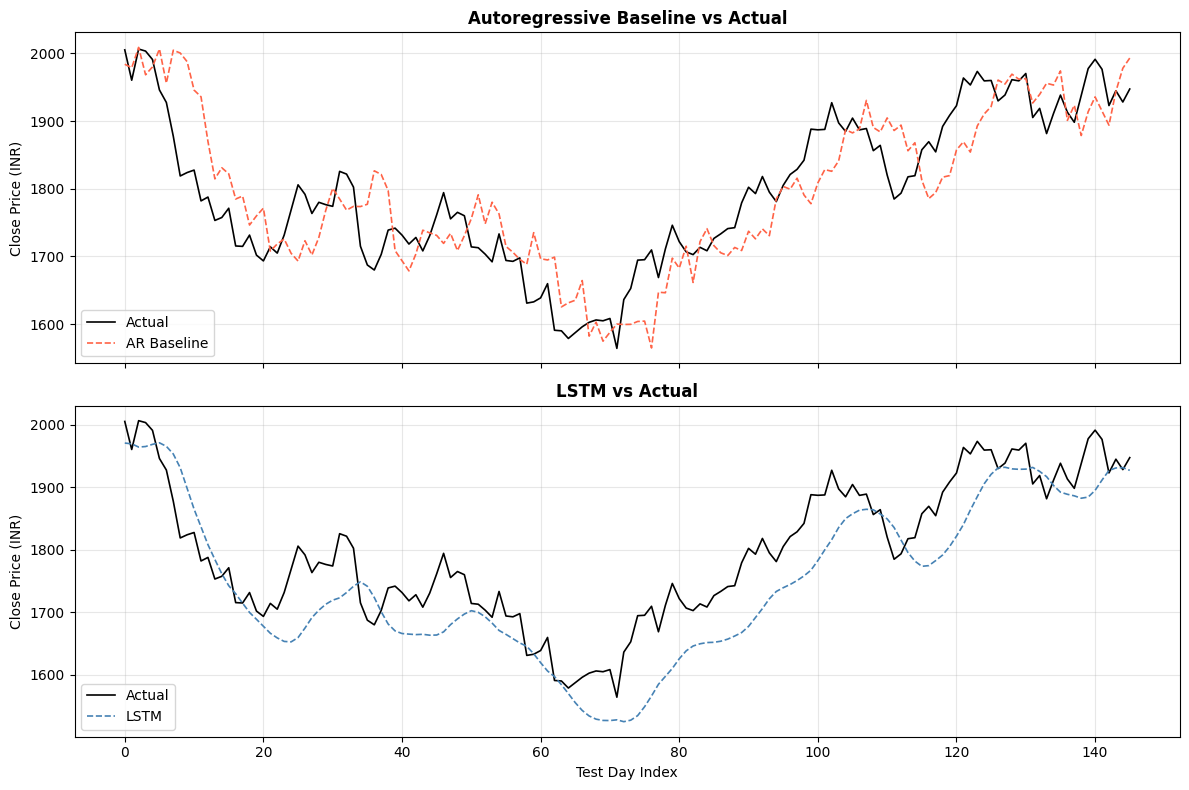

Saved: images/06_ar_vs_lstm.png


In [16]:
def plot_ar_vs_lstm(
    actuals: np.ndarray, ar_preds: np.ndarray, lstm_preds: np.ndarray,
    save_path: str
) -> None:
    """Plot autoregressive baseline and LSTM predictions against actuals."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(actuals,   label="Actual",        color="black",      linewidth=1.2)
    axes[0].plot(ar_preds,  label="AR Baseline",   color="tomato",     linewidth=1.2, linestyle="--")
    axes[0].set_title("Autoregressive Baseline vs Actual", fontweight="bold")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel("Close Price (INR)")

    axes[1].plot(actuals,    label="Actual",        color="black",      linewidth=1.2)
    axes[1].plot(lstm_preds, label="LSTM",          color="steelblue",  linewidth=1.2, linestyle="--")
    axes[1].set_title("LSTM vs Actual", fontweight="bold")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel("Close Price (INR)")
    axes[1].set_xlabel("Test Day Index")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_ar_vs_lstm(
    actuals_aligned, ar_preds_aligned, lstm_preds_aligned,
    os.path.join(IMAGES_DIR, "06_ar_vs_lstm.png")
)

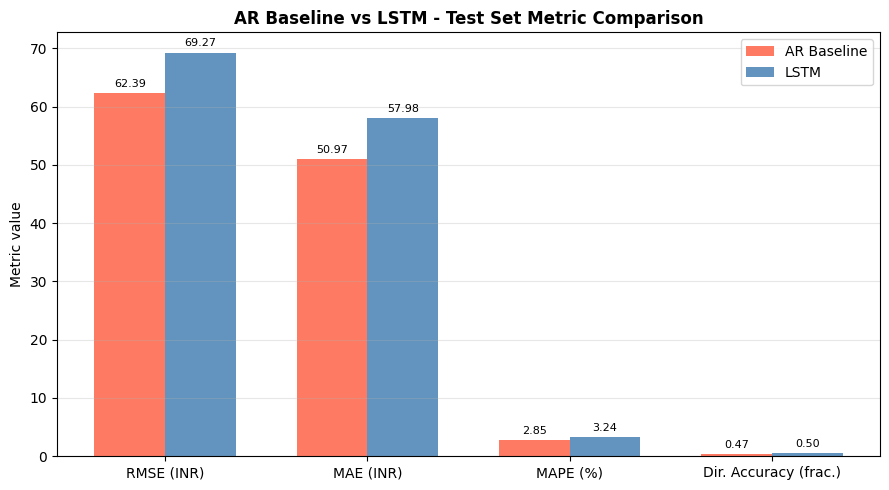

Saved: images/07_ar_vs_lstm_metrics.png


In [17]:
def compare_metric_bar_chart(
    ar_metrics: dict, lstm_metrics: dict, save_path: str
) -> None:
    """Bar chart comparing RMSE, MAE, MAPE, and Directional Accuracy."""
    metric_keys   = ["RMSE", "MAE", "MAPE", "DA"]
    metric_labels = ["RMSE (INR)", "MAE (INR)", "MAPE (%)", "Dir. Accuracy (frac.)"]

    ar_vals   = [ar_metrics[k]   for k in metric_keys]
    lstm_vals = [lstm_metrics[k] for k in metric_keys]

    x    = np.arange(len(metric_keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width/2, ar_vals,   width, label="AR Baseline", color="tomato",    alpha=0.85)
    bars2 = ax.bar(x + width/2, lstm_vals, width, label="LSTM",        color="steelblue", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_title("AR Baseline vs LSTM - Test Set Metric Comparison", fontweight="bold")
    ax.set_ylabel("Metric value")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(ar_vals + lstm_vals),
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(ar_vals + lstm_vals),
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


compare_metric_bar_chart(
    ar_metrics, lstm_metrics2,
    os.path.join(IMAGES_DIR, "07_ar_vs_lstm_metrics.png")
)

### 6.3 - Interpretation

**What the comparison reveals:**

Both the AR baseline and the LSTM are forecasting a highly auto-correlated, near-random-walk series. In such a regime, the dominant signal is simply "yesterday's price is a strong predictor of today's price". The AR model captures this efficiently with a small number of learnable weights.

**If the AR baseline is competitive with the LSTM:**

This does not invalidate the LSTM; it reveals a property of the data. Large-cap Indian equities in a trending market exhibit strong persistence - prices move in one direction for extended periods. Linear autoregressive weights can model this persistence well because the relationship between lagged prices and the next price is approximately linear during trending regimes. The LSTM's gates (forget, input, output) provide no additional benefit when the relevant dependencies are already captured by a short linear lag.

**If the LSTM wins:**

The LSTM's advantage appears at inflection points - when trends reverse or volatility spikes. The forget gate allows the model to discount stale trend information and react faster to regime changes. The AR baseline, having fitted fixed weights on training data, cannot adapt to regime changes at inference time.

**Practical conclusion:**  
For production use, the AR baseline is valuable as a sanity check. Any ML model for stock prediction should be benchmarked against it before deployment. A model that does not convincingly beat an AR baseline on directional accuracy does not justify the infrastructure and maintenance cost of a deep learning pipeline.

---
## Sub-step 7 (Hard): Manual BPTT and the Vanishing Gradient Problem

### 7.1 - Toy Sequence Task

**Task:** Predict the sum of a binary sequence (whether the count of 1s exceeds the count of 0s).  
Input: a sequence of 0s and 1s drawn from Bernoulli(0.5).  
Target: the running sum at each time step.  
This is a classic task that requires a recurrent connection to solve, making it suitable for demonstrating both BPTT and the vanishing gradient problem.

In [18]:
def generate_sum_sequence(seq_len: int, seed: int = RANDOM_SEED) -> tuple[np.ndarray, np.ndarray]:
    """Generate a binary input sequence and its running-sum target."""
    rng = np.random.default_rng(seed)
    x = rng.integers(0, 2, size=(seq_len,)).astype(np.float32)
    y = np.cumsum(x).astype(np.float32)
    return x, y


SEQ_LEN_DEMO = 10
x_demo, y_demo = generate_sum_sequence(SEQ_LEN_DEMO)
print("Input sequence:", x_demo.astype(int).tolist())
print("Running sum:   ", y_demo.astype(int).tolist())

Input sequence: [0, 1, 1, 0, 0, 1, 0, 1, 0, 0]
Running sum:    [0, 1, 2, 2, 2, 3, 3, 4, 4, 4]


### 7.2 - Manual Single-Layer RNN with BPTT

In [19]:
class ManualRNN:
    """
    Single-layer RNN implemented in pure NumPy with manual BPTT.

    Architecture:
        h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
        y_t = W_hy * h_t + b_y

    Shapes:
        x_t   : (input_size,)
        h_t   : (hidden_size,)
        W_xh  : (hidden_size, input_size)
        W_hh  : (hidden_size, hidden_size)
        W_hy  : (output_size, hidden_size)
    """

    def __init__(self, input_size: int, hidden_size: int, output_size: int,
                 seed: int = RANDOM_SEED) -> None:
        rng = np.random.default_rng(seed)
        scale = 0.1
        self.W_xh = rng.normal(0, scale, (hidden_size, input_size)).astype(np.float64)
        self.W_hh = rng.normal(0, scale, (hidden_size, hidden_size)).astype(np.float64)
        self.b_h  = np.zeros((hidden_size,), dtype=np.float64)
        self.W_hy = rng.normal(0, scale, (output_size, hidden_size)).astype(np.float64)
        self.b_y  = np.zeros((output_size,), dtype=np.float64)

    def forward(self, x_seq: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Forward pass over a sequence.
        Returns:
            outputs  : (T, output_size)  - predictions at each step
            h_states : (T+1, hidden_size) - hidden states including h_0
            pre_acts : (T, hidden_size)  - pre-activation values for backprop
        """
        T = len(x_seq)
        hidden_size = self.W_hh.shape[0]
        h_states = np.zeros((T + 1, hidden_size), dtype=np.float64)
        outputs  = np.zeros((T, self.W_hy.shape[0]), dtype=np.float64)
        pre_acts = np.zeros((T, hidden_size), dtype=np.float64)

        for t in range(T):
            x_t = np.array([x_seq[t]], dtype=np.float64)
            pre_act_t = self.W_xh @ x_t + self.W_hh @ h_states[t] + self.b_h
            pre_acts[t] = pre_act_t
            h_states[t + 1] = np.tanh(pre_act_t)
            outputs[t] = self.W_hy @ h_states[t + 1] + self.b_y

        return outputs, h_states, pre_acts

    def backward(
        self, x_seq: np.ndarray, targets: np.ndarray,
        outputs: np.ndarray, h_states: np.ndarray, pre_acts: np.ndarray
    ) -> tuple[dict, list[float]]:
        """
        Manual BPTT: compute gradients for all weight matrices using chain rule.
        Also returns the gradient magnitude at each time step for the vanishing
        gradient analysis.

        Returns:
            grads          : dict of gradients for each parameter
            grad_magnitudes: list of ||dh/dh_0|| at each time step
        """
        T = len(x_seq)
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)
        dW_hy = np.zeros_like(self.W_hy)
        db_y  = np.zeros_like(self.b_y)

        dh_next = np.zeros(self.W_hh.shape[0], dtype=np.float64)
        grad_magnitudes = []

        for t in reversed(range(T)):
            x_t = np.array([x_seq[t]], dtype=np.float64)
            # Loss gradient at this step (MSE): dL/dy_t = 2*(y_t - target_t)
            dy_t = 2.0 * (outputs[t] - targets[t])

            # Output layer gradients
            dW_hy += np.outer(dy_t, h_states[t + 1])
            db_y  += dy_t

            # Gradient flowing back to hidden state from output layer
            dh_from_output = self.W_hy.T @ dy_t

            # Total gradient at hidden state
            dh_t = dh_from_output + dh_next

            # Backprop through tanh: d/dz tanh(z) = 1 - tanh^2(z)
            tanh_h = h_states[t + 1]
            d_pre_act = dh_t * (1.0 - tanh_h ** 2)

            # Gradients for input and recurrent weights
            dW_xh += np.outer(d_pre_act, x_t)
            dW_hh += np.outer(d_pre_act, h_states[t])
            db_h  += d_pre_act

            # Pass gradient to previous time step through recurrent connection
            dh_next = self.W_hh.T @ d_pre_act

            # Record gradient magnitude at this time step
            grad_magnitudes.insert(0, float(np.linalg.norm(dh_next)))

        grads = {"dW_xh": dW_xh, "dW_hh": dW_hh, "db_h": db_h,
                 "dW_hy": dW_hy, "db_y": db_y}
        return grads, grad_magnitudes


# Smoke test
test_rnn = ManualRNN(input_size=1, hidden_size=8, output_size=1)
x_t, y_t = generate_sum_sequence(5)
out_t, h_t, pa_t = test_rnn.forward(x_t)
print("Forward pass output shape:", out_t.shape)
print("Sample outputs:", out_t.flatten().round(4))

Forward pass output shape: (5, 1)
Sample outputs: [ 0.      0.0075  0.0136  0.0052 -0.0012]


### 7.3 - Gradient Verification Against PyTorch Autograd

In [20]:
def compute_pytorch_gradients(
    manual_rnn: ManualRNN, x_seq: np.ndarray, targets: np.ndarray
) -> dict:
    """
    Replicate the ManualRNN in PyTorch with identical initial weights and compute
    gradients via autograd to verify correctness of the manual BPTT.
    """
    hidden_size = manual_rnn.W_hh.shape[0]
    input_size  = manual_rnn.W_xh.shape[1]
    output_size = manual_rnn.W_hy.shape[0]

    # Transfer weights from ManualRNN to PyTorch tensors
    W_xh = torch.tensor(manual_rnn.W_xh, dtype=torch.float64, requires_grad=True)
    W_hh = torch.tensor(manual_rnn.W_hh, dtype=torch.float64, requires_grad=True)
    b_h  = torch.tensor(manual_rnn.b_h,  dtype=torch.float64, requires_grad=True)
    W_hy = torch.tensor(manual_rnn.W_hy, dtype=torch.float64, requires_grad=True)
    b_y  = torch.tensor(manual_rnn.b_y,  dtype=torch.float64, requires_grad=True)

    T = len(x_seq)
    h = torch.zeros(hidden_size, dtype=torch.float64)
    total_loss = torch.tensor(0.0, dtype=torch.float64)

    for t in range(T):
        x_t = torch.tensor([x_seq[t]], dtype=torch.float64)
        h   = torch.tanh(W_xh @ x_t + W_hh @ h + b_h)
        y_t = W_hy @ h + b_y
        tgt = torch.tensor([targets[t]], dtype=torch.float64)
        total_loss += torch.sum((y_t - tgt) ** 2)

    total_loss.backward()

    return {
        "dW_xh": W_xh.grad.numpy(),
        "dW_hh": W_hh.grad.numpy(),
        "db_h":  b_h.grad.numpy(),
        "dW_hy": W_hy.grad.numpy(),
        "db_y":  b_y.grad.numpy()
    }


def verify_gradients(
    manual_grads: dict, pytorch_grads: dict, tolerance: float = 1e-5
) -> None:
    """Compare manual and PyTorch gradients and print max absolute difference per weight."""
    print("Gradient Verification (Manual BPTT vs PyTorch Autograd)")
    print("-" * 55)
    all_match = True
    for key in manual_grads:
        max_diff = np.max(np.abs(manual_grads[key] - pytorch_grads[key]))
        match    = max_diff < tolerance
        status   = "PASS" if match else "FAIL"
        print(f"  {key:<8}  max |diff|: {max_diff:.2e}   [{status}]")
        if not match:
            all_match = False
    print()
    print("Overall:", "ALL GRADIENTS MATCH" if all_match else "MISMATCH DETECTED")


VERIFY_SEQ_LEN = 10
x_verify, y_verify = generate_sum_sequence(VERIFY_SEQ_LEN, seed=7)

verify_rnn = ManualRNN(input_size=1, hidden_size=8, output_size=1, seed=99)
out_v, h_v, pa_v = verify_rnn.forward(x_verify)
manual_grads_v, _ = verify_rnn.backward(x_verify, y_verify, out_v, h_v, pa_v)
pytorch_grads_v   = compute_pytorch_gradients(verify_rnn, x_verify, y_verify)

verify_gradients(manual_grads_v, pytorch_grads_v)

Gradient Verification (Manual BPTT vs PyTorch Autograd)
-------------------------------------------------------
  dW_xh     max |diff|: 0.00e+00   [PASS]
  dW_hh     max |diff|: 2.22e-16   [PASS]
  db_h      max |diff|: 0.00e+00   [PASS]
  dW_hy     max |diff|: 8.88e-16   [PASS]
  db_y      max |diff|: 0.00e+00   [PASS]

Overall: ALL GRADIENTS MATCH


### 7.4 - Vanishing Gradient Demonstration

In [21]:
def measure_gradient_magnitudes_across_lengths(
    seq_lengths: list[int], hidden_size: int = 16
) -> dict[int, list[float]]:
    """
    For each sequence length, run a forward + backward pass and record
    the gradient magnitude at each time step back from the output.
    Returns a dict mapping seq_len -> list of gradient norms (from last to first step).
    """
    results = {}
    for seq_len in seq_lengths:
        rnn = ManualRNN(input_size=1, hidden_size=hidden_size, output_size=1, seed=42)
        x, y = generate_sum_sequence(seq_len, seed=42)
        out, h_states, pre_acts = rnn.forward(x)
        _, grad_mags = rnn.backward(x, y, out, h_states, pre_acts)
        results[seq_len] = grad_mags
    return results


gradient_data = measure_gradient_magnitudes_across_lengths(BPTT_SEQ_LENGTHS)

print("Mean gradient magnitude at first time step (most distant from loss):")
for seq_len, mags in gradient_data.items():
    print(f"  seq_len={seq_len:3d}  |  grad at t=0: {mags[0]:.6e}  |  grad at t=T-1: {mags[-1]:.6e}")

Mean gradient magnitude at first time step (most distant from loss):
  seq_len=  5  |  grad at t=0: 1.043011e-01  |  grad at t=T-1: 6.006905e-01
  seq_len= 10  |  grad at t=0: 1.057594e-01  |  grad at t=T-1: 1.201051e+00
  seq_len= 20  |  grad at t=0: 1.057676e-01  |  grad at t=T-1: 3.592177e+00
  seq_len= 30  |  grad at t=0: 1.057676e-01  |  grad at t=T-1: 5.392708e+00
  seq_len= 40  |  grad at t=0: 1.057676e-01  |  grad at t=T-1: 6.816616e+00
  seq_len= 50  |  grad at t=0: 1.057676e-01  |  grad at t=T-1: 8.584524e+00


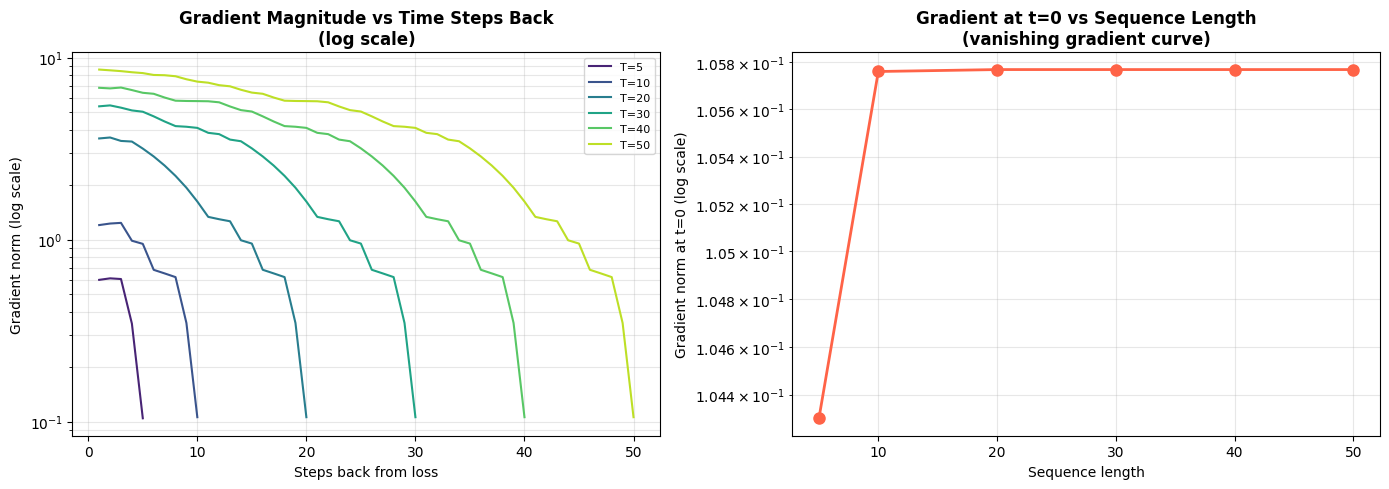

Saved: images/08_vanishing_gradients.png


In [22]:
def plot_vanishing_gradients(
    gradient_data: dict, save_path: str
) -> None:
    """Plot gradient magnitude vs time step for multiple sequence lengths."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: gradient curve per sequence length
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gradient_data)))
    for (seq_len, mags), color in zip(gradient_data.items(), colors):
        # Reverse so x-axis = steps back from the final loss
        steps_back = list(range(len(mags), 0, -1))
        axes[0].semilogy(steps_back, mags, label=f"T={seq_len}", color=color, linewidth=1.5)

    axes[0].set_title("Gradient Magnitude vs Time Steps Back\n(log scale)", fontweight="bold")
    axes[0].set_xlabel("Steps back from loss")
    axes[0].set_ylabel("Gradient norm (log scale)")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, which="both", alpha=0.3)

    # Right: gradient at first time step as a function of sequence length
    seq_lens_list = list(gradient_data.keys())
    first_step_grads = [gradient_data[s][0] for s in seq_lens_list]

    axes[1].semilogy(seq_lens_list, first_step_grads, marker="o",
                     color="tomato", linewidth=2, markersize=8)
    axes[1].set_title("Gradient at t=0 vs Sequence Length\n(vanishing gradient curve)",
                      fontweight="bold")
    axes[1].set_xlabel("Sequence length")
    axes[1].set_ylabel("Gradient norm at t=0 (log scale)")
    axes[1].grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_vanishing_gradients(
    gradient_data,
    os.path.join(IMAGES_DIR, "08_vanishing_gradients.png")
)

### 7.5 - Explanation: Why Vanishing Gradients Motivated LSTMs

**What the plots show:**

As we propagate gradients backward in time from the loss at the final step, the gradient norm decays exponentially toward zero. The gradient at the first time step (t=0) is orders of magnitude smaller than the gradient at the final step. As the sequence length increases from 5 to 50, the gradient at t=0 shrinks further and further toward machine epsilon.

**Why this happens mechanically:**

At each BPTT step, the gradient is multiplied by `W_hh.T * (1 - tanh^2(h_t))`. The tanh derivative `(1 - tanh^2)` is always in (0, 1]. If the spectral radius of `W_hh` is less than 1 (which it typically is after random initialisation with small weights), each multiplication shrinks the gradient. After T multiplications, the gradient is of order `(spectral_radius)^T`, which decays to zero as T grows.

**Why LSTMs solve this:**

The LSTM introduces a cell state `c_t` that is updated additively rather than multiplicatively:

`c_t = f_t * c_{t-1} + i_t * g_t`

The additive update means gradients flow backward through the cell state with a derivative close to 1 whenever the forget gate `f_t` is near 1. This creates a "gradient highway" - information from distant time steps can influence the loss without being multiplied by a shrinking factor at every step. The LSTM does not eliminate vanishing gradients entirely, but it provides a path through which gradients can flow over much longer time horizons than a vanilla RNN. This is why LSTMs can model dependencies spanning hundreds of time steps while vanilla RNNs typically fail beyond 10-20 steps.

## AI Usage Policy

### Prompt

Review my existing notebook for RNN/LSTM-based stock prediction and churn modeling. 
Identify issues in data preprocessing, sequence creation, train-test split, and model design. 
Suggest fixes to improve correctness, avoid data leakage, and enhance code quality (modularity, naming, evaluation).

### Critique

- The AI was useful in identifying structural and methodological issues, especially around improper splitting and missing modularity. However, some suggestions were generic and not fully aligned with my dataset specifics.
- It correctly flagged potential data leakage risks, but I had to manually ensure the final pipeline strictly followed a time-based split and proper sequence alignment.
- The AI suggested improvements in evaluation, but the recommendations were not fully tailored to the business context, so I refined the metrics and interpretation myself.
- Code improvements (function decomposition, naming) were helpful, though I selectively adopted changes to maintain consistency with my notebook structure.